<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB3_%ED%94%84%EB%A1%9C%EC%A0%9D%ED%8A%B81_%EC%9D%B4%EC%97%B0%EC%88%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

hotel_train=pd.read_csv('/content/drive/MyDrive/Colab/ESAA/train.csv')
hotel_test=pd.read_csv('/content/drive/MyDrive/Colab/ESAA/test.csv')

In [ ]:
hotel_train.head(5)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN09079,2,0,1,2,Meal Plan 1,0,Room_Type 1,273,2018,5,13,Offline,0,0,0,95.00,0,Canceled
1,INN36043,2,0,1,3,Meal Plan 1,0,Room_Type 1,158,2018,6,30,Online,0,0,0,90.95,1,Canceled
2,INN05930,2,0,2,1,Meal Plan 1,0,Room_Type 1,59,2018,11,26,Online,0,0,0,93.60,1,Not_Canceled
3,INN06929,1,0,0,2,Meal Plan 1,0,Room_Type 1,5,2018,10,25,Aviation,0,0,0,95.00,0,Not_Canceled
4,INN34608,2,2,2,4,Meal Plan 1,0,Room_Type 6,54,2018,4,29,Online,0,0,0,187.85,0,Canceled


In [ ]:
hotel_test.head(5)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,INN10011,3,0,1,2,Meal Plan 1,0,Room_Type 1,165,2018,8,12,Online,0,0,0,146.70,0
1,INN11434,2,0,0,1,Meal Plan 1,0,Room_Type 1,4,2018,9,15,Online,0,0,0,169.00,0
2,INN21620,2,0,0,2,Meal Plan 1,0,Room_Type 1,59,2018,6,22,Online,0,0,0,99.90,2
3,INN26405,1,0,0,3,Meal Plan 1,0,Room_Type 4,28,2018,6,14,Online,0,0,0,108.42,1
4,INN23445,1,0,0,2,Meal Plan 2,0,Room_Type 1,74,2017,9,18,Offline,0,0,0,87.00,0


In [ ]:
hotel_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29020 entries, 0 to 29019
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            29020 non-null  object 
 1   no_of_adults                          29020 non-null  int64  
 2   no_of_children                        29020 non-null  int64  
 3   no_of_weekend_nights                  29020 non-null  int64  
 4   no_of_week_nights                     29020 non-null  int64  
 5   type_of_meal_plan                     29020 non-null  object 
 6   required_car_parking_space            29020 non-null  int64  
 7   room_type_reserved                    29020 non-null  object 
 8   lead_time                             29020 non-null  int64  
 9   arrival_year                          29020 non-null  int64  
 10  arrival_month                         29020 non-null  int64  
 11  arrival_date   

In [ ]:
hotel_train.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000,29020.000000
mean,1.846623,0.104859,0.810855,2.203308,0.031496,85.127016,2017.820193,7.431978,15.580875,0.025775,0.022674,0.157960,103.533282,0.620331
std,0.518991,0.402785,0.871787,1.415096,0.174656,85.921809,0.384033,3.070065,8.728470,0.158467,0.368525,1.796362,35.147072,0.788429
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.492500,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.900000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.600000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


## 전처리 - 인코딩

### 범주형 칼럼 인코딩

In [ ]:
# type_of_meal_plan을 Not Selected=0, Meal Plan 숫자에 따라 1, 2, 3 매기는 레이블 인코딩
meal_plan_mapping={
    'Not Selected': 0,
    'Meal Plan 1': 1,
    'Meal Plan 2': 2,
    'Meal Plan 3': 3
}
hotel_train['type_of_meal_plan']=hotel_train['type_of_meal_plan'].map(meal_plan_mapping)

In [ ]:
# room_type_reserved을 Room_Type 숫자에 따라 1~7 매기는 레이블 인코딩
room_type_mapping={
    'Room_Type 1': 1,
    'Room_Type 2': 2,
    'Room_Type 3': 3,
    'Room_Type 4': 4,
    'Room_Type 5': 5,
    'Room_Type 6': 6,
    'Room_Type 7': 7
}
hotel_train['room_type_reserved']=hotel_train['room_type_reserved'].map(room_type_mapping)

In [ ]:
# market_segment_type을 레이블 인코딩
market_segment_mapping={
    'Offline': 0,
    'Online': 1,
    'Corporate': 2,
    'Aviation': 3,
    'Complementary': 4
}
hotel_train['market_segment_type']=hotel_train['market_segment_type'].map(market_segment_mapping)

In [ ]:
# booking_status를 레이블 인코딩
booking_status_mapping={
    'Not_Canceled': 0,
    'Canceled': 1
}
hotel_train['booking_status']=hotel_train['booking_status'].map(booking_status_mapping)

In [ ]:
hotel_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29020 entries, 0 to 29019
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            29020 non-null  object 
 1   no_of_adults                          29020 non-null  int64  
 2   no_of_children                        29020 non-null  int64  
 3   no_of_weekend_nights                  29020 non-null  int64  
 4   no_of_week_nights                     29020 non-null  int64  
 5   type_of_meal_plan                     29020 non-null  int64  
 6   required_car_parking_space            29020 non-null  int64  
 7   room_type_reserved                    29020 non-null  int64  
 8   lead_time                             29020 non-null  int64  
 9   arrival_year                          29020 non-null  int64  
 10  arrival_month                         29020 non-null  int64  
 11  arrival_date   

## EDA

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_6431/3574972366.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel_train, x=col, palette='viridis')
/tmp/ipykernel_6431/3574972366.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel_train, x=col, palette='viridis')
/tmp/ipykernel_6431/3574972366.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=hotel_train, x=col, palette='viridis')
/tmp/ipykernel_6431/3574972366.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x`

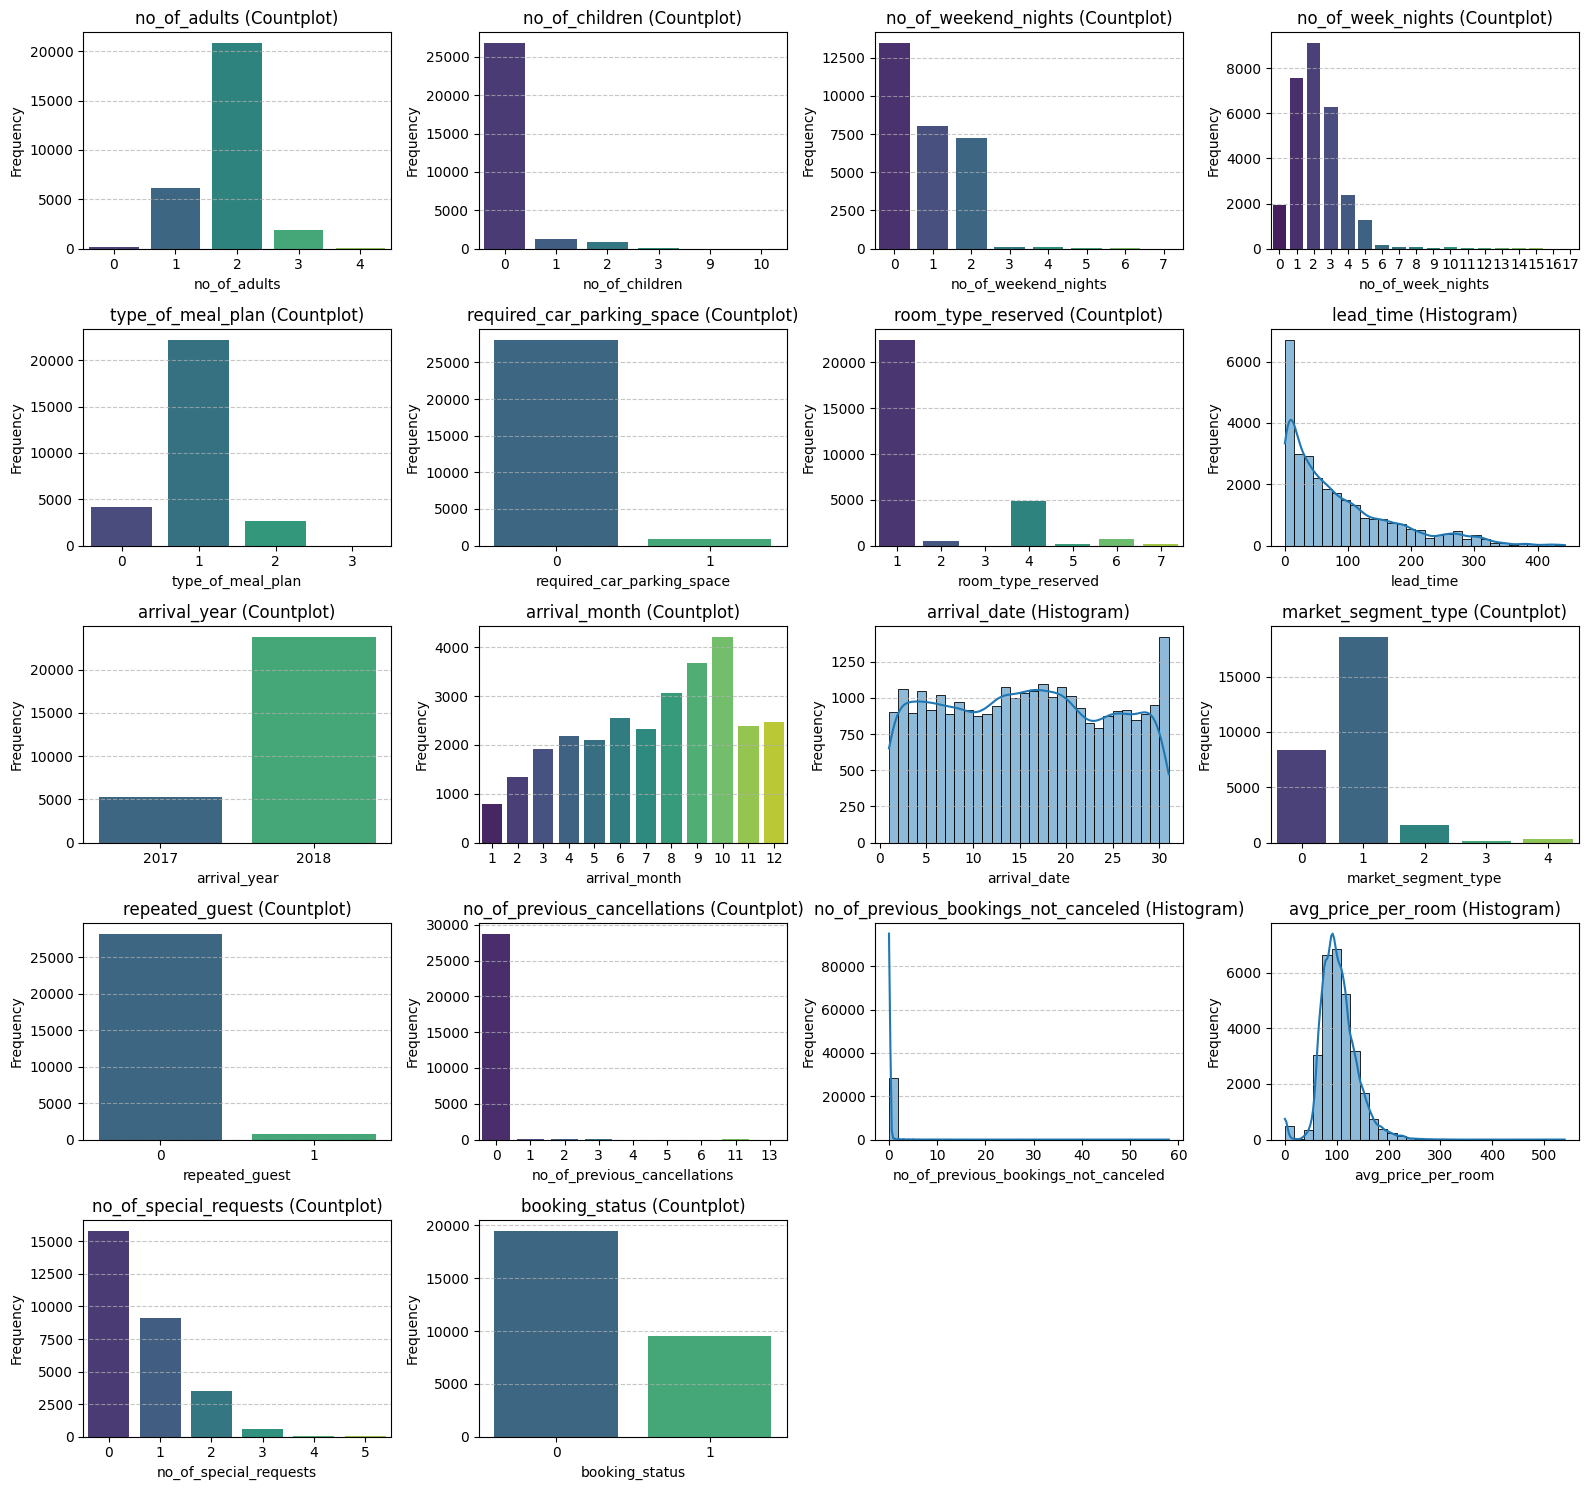

In [ ]:
import math

numerical_cols = hotel_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'Booking_ID' in numerical_cols:
    numerical_cols.remove('Booking_ID')

num_plots = len(numerical_cols)
num_cols_grid = 4  # You can adjust this number for desired grid width
num_rows_grid = math.ceil(num_plots / num_cols_grid)

plt.figure(figsize=(num_cols_grid * 4, num_rows_grid * 3)) # Adjust overall figure size

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows_grid, num_cols_grid, i + 1)

    if hotel_train[col].nunique() < 20 and hotel_train[col].dtype == 'int64':
        sns.countplot(data=hotel_train, x=col, palette='viridis')
        plt.title(f'{col} (Countplot)')
    else:
        sns.histplot(data=hotel_train, x=col, kde=True, bins=30, palette='viridis')
        plt.title(f'{col} (Histogram)')

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 추가 전처리 관련

#### no_of_weekend_nights와 no_of_week_nights 전처리

---



In [ ]:
# 총 숙박일수 total_nights 파생변수 생성
hotel_train['total_nights']=(
    hotel_train['no_of_weekend_nights']+hotel_train['no_of_week_nights']
)

#### lead_time

In [ ]:
# lead_time 로그 변환 후 스케일링

import numpy as np
from sklearn.preprocessing import StandardScaler

hotel_train['lead_time_log']=np.log1p(hotel_train['lead_time'])

scaler=StandardScaler()
hotel_train['lead_time_scaled']=scaler.fit_transform(hotel_train[['lead_time_log']])

#### 도착 년/월/일

In [ ]:
# 날짜 피처를 결합해 통합된 날짜 변수 생성

hotel_train['arrival_day']=pd.to_datetime(
    hotel_train['arrival_year'].astype(str)+'-'+
    hotel_train['arrival_month'].astype(str)+'-'+
    hotel_train['arrival_date'].astype(str),
    errors='coerce'  # 31일 없는 달 NaT 처리
)

In [ ]:
# 월/일에 사이클릭 인코딩
import numpy as np

hotel_train['month_sin']=np.sin(2*np.pi*hotel_train['arrival_month']/12)
hotel_train['month_cos']=np.cos(2*np.pi*hotel_train['arrival_month']/12)

hotel_train['date_sin']=np.sin(2*np.pi*hotel_train['arrival_date']/31)
hotel_train['date_cos']=np.cos(2*np.pi*hotel_train['arrival_date']/31)

#### avg_price_per_room

In [ ]:
# 로그 변환해도 괜찮을지 skew로 판단
skewness=hotel_train['avg_price_per_room'].skew()
print(f"Skewness: {skewness}")

Skewness: 0.6745721300226


In [ ]:
# skewness < 1 이므로 로그 변환 X
# RobustScaler로 스케일링 진행
from sklearn.preprocessing import RobustScaler

scaler=RobustScaler()
hotel_train['avg_price_per_room_scaled']=scaler.fit_transform(hotel_train[['avg_price_per_room']])

#### repeated_guest와 no_of_previous_cancellations와 no_of_previous_bookings_not_canceled 파생변수

In [ ]:
# 세 변수 간 관계
mask=hotel_train['repeated_guest']==1
print(hotel_train.loc[mask,['no_of_previous_cancellations',
                            'no_of_previous_bookings_not_canceled']].describe())

       no_of_previous_cancellations  no_of_previous_bookings_not_canceled
count                    748.000000                            748.000000
mean                       0.879679                              6.128342
std                        2.126259                              9.419118
min                        0.000000                              0.000000
25%                        0.000000                              1.000000
50%                        0.000000                              3.000000
75%                        1.000000                              7.000000
max                       13.000000                             58.000000


In [ ]:
print(pd.crosstab(
    hotel_train['repeated_guest'],
    hotel_train['no_of_previous_bookings_not_canceled']>0
))

no_of_previous_bookings_not_canceled  False  True 
repeated_guest                                    
0                                     28272      0
1                                        90    658


In [ ]:
# 총 예약횟수 total_previous_bookings
hotel_train['total_previous_bookings']=(
    hotel_train['no_of_previous_cancellations']+hotel_train['no_of_previous_bookings_not_canceled']
)

### 변수 드랍

In [ ]:
display(hotel_train[hotel_train['arrival_day'].isnull()][['arrival_year', 'arrival_month', 'arrival_date', 'arrival_day', 'booking_status']])

,arrival_year,arrival_month,arrival_date,arrival_day,booking_status
768,2018,2,29,NaT,0
3357,2018,2,29,NaT,0
4073,2018,2,29,NaT,0
4612,2018,2,29,NaT,1
5516,2018,2,29,NaT,0
6480,2018,2,29,NaT,0
7009,2018,2,29,NaT,0
8631,2018,2,29,NaT,1
10401,2018,2,29,NaT,1
12755,2018,2,29,NaT,0


#### 변수 1차 드랍

In [ ]:
drop_columns1=[
    'Booking_ID','arrival_day','arrival_year'
]
hotel_train.drop(columns=drop_columns1,inplace=True)
hotel_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29020 entries, 0 to 29019
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          29020 non-null  int64  
 1   no_of_children                        29020 non-null  int64  
 2   no_of_weekend_nights                  29020 non-null  int64  
 3   no_of_week_nights                     29020 non-null  int64  
 4   type_of_meal_plan                     29020 non-null  int64  
 5   required_car_parking_space            29020 non-null  int64  
 6   room_type_reserved                    29020 non-null  int64  
 7   lead_time                             29020 non-null  int64  
 8   arrival_month                         29020 non-null  int64  
 9   arrival_date                          29020 non-null  int64  
 10  market_segment_type                   29020 non-null  int64  
 11  repeated_guest 

#### 변수 2차 드랍

- arrival_month, arrival_day 드랍 X (트리 계열 모델링에 이용될 수 있음. 이후 Feature Importance로 확인.)
- lead_time_log 드랍 O, avg_price_per_room는 원본 유지(XGBoost, RandomForest 용도)

In [ ]:
hotel_train.drop(columns=['lead_time_log'],inplace=True)

In [ ]:
hotel_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29020 entries, 0 to 29019
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          29020 non-null  int64  
 1   no_of_children                        29020 non-null  int64  
 2   no_of_weekend_nights                  29020 non-null  int64  
 3   no_of_week_nights                     29020 non-null  int64  
 4   type_of_meal_plan                     29020 non-null  int64  
 5   required_car_parking_space            29020 non-null  int64  
 6   room_type_reserved                    29020 non-null  int64  
 7   lead_time                             29020 non-null  int64  
 8   arrival_month                         29020 non-null  int64  
 9   arrival_date                          29020 non-null  int64  
 10  market_segment_type                   29020 non-null  int64  
 11  repeated_guest 

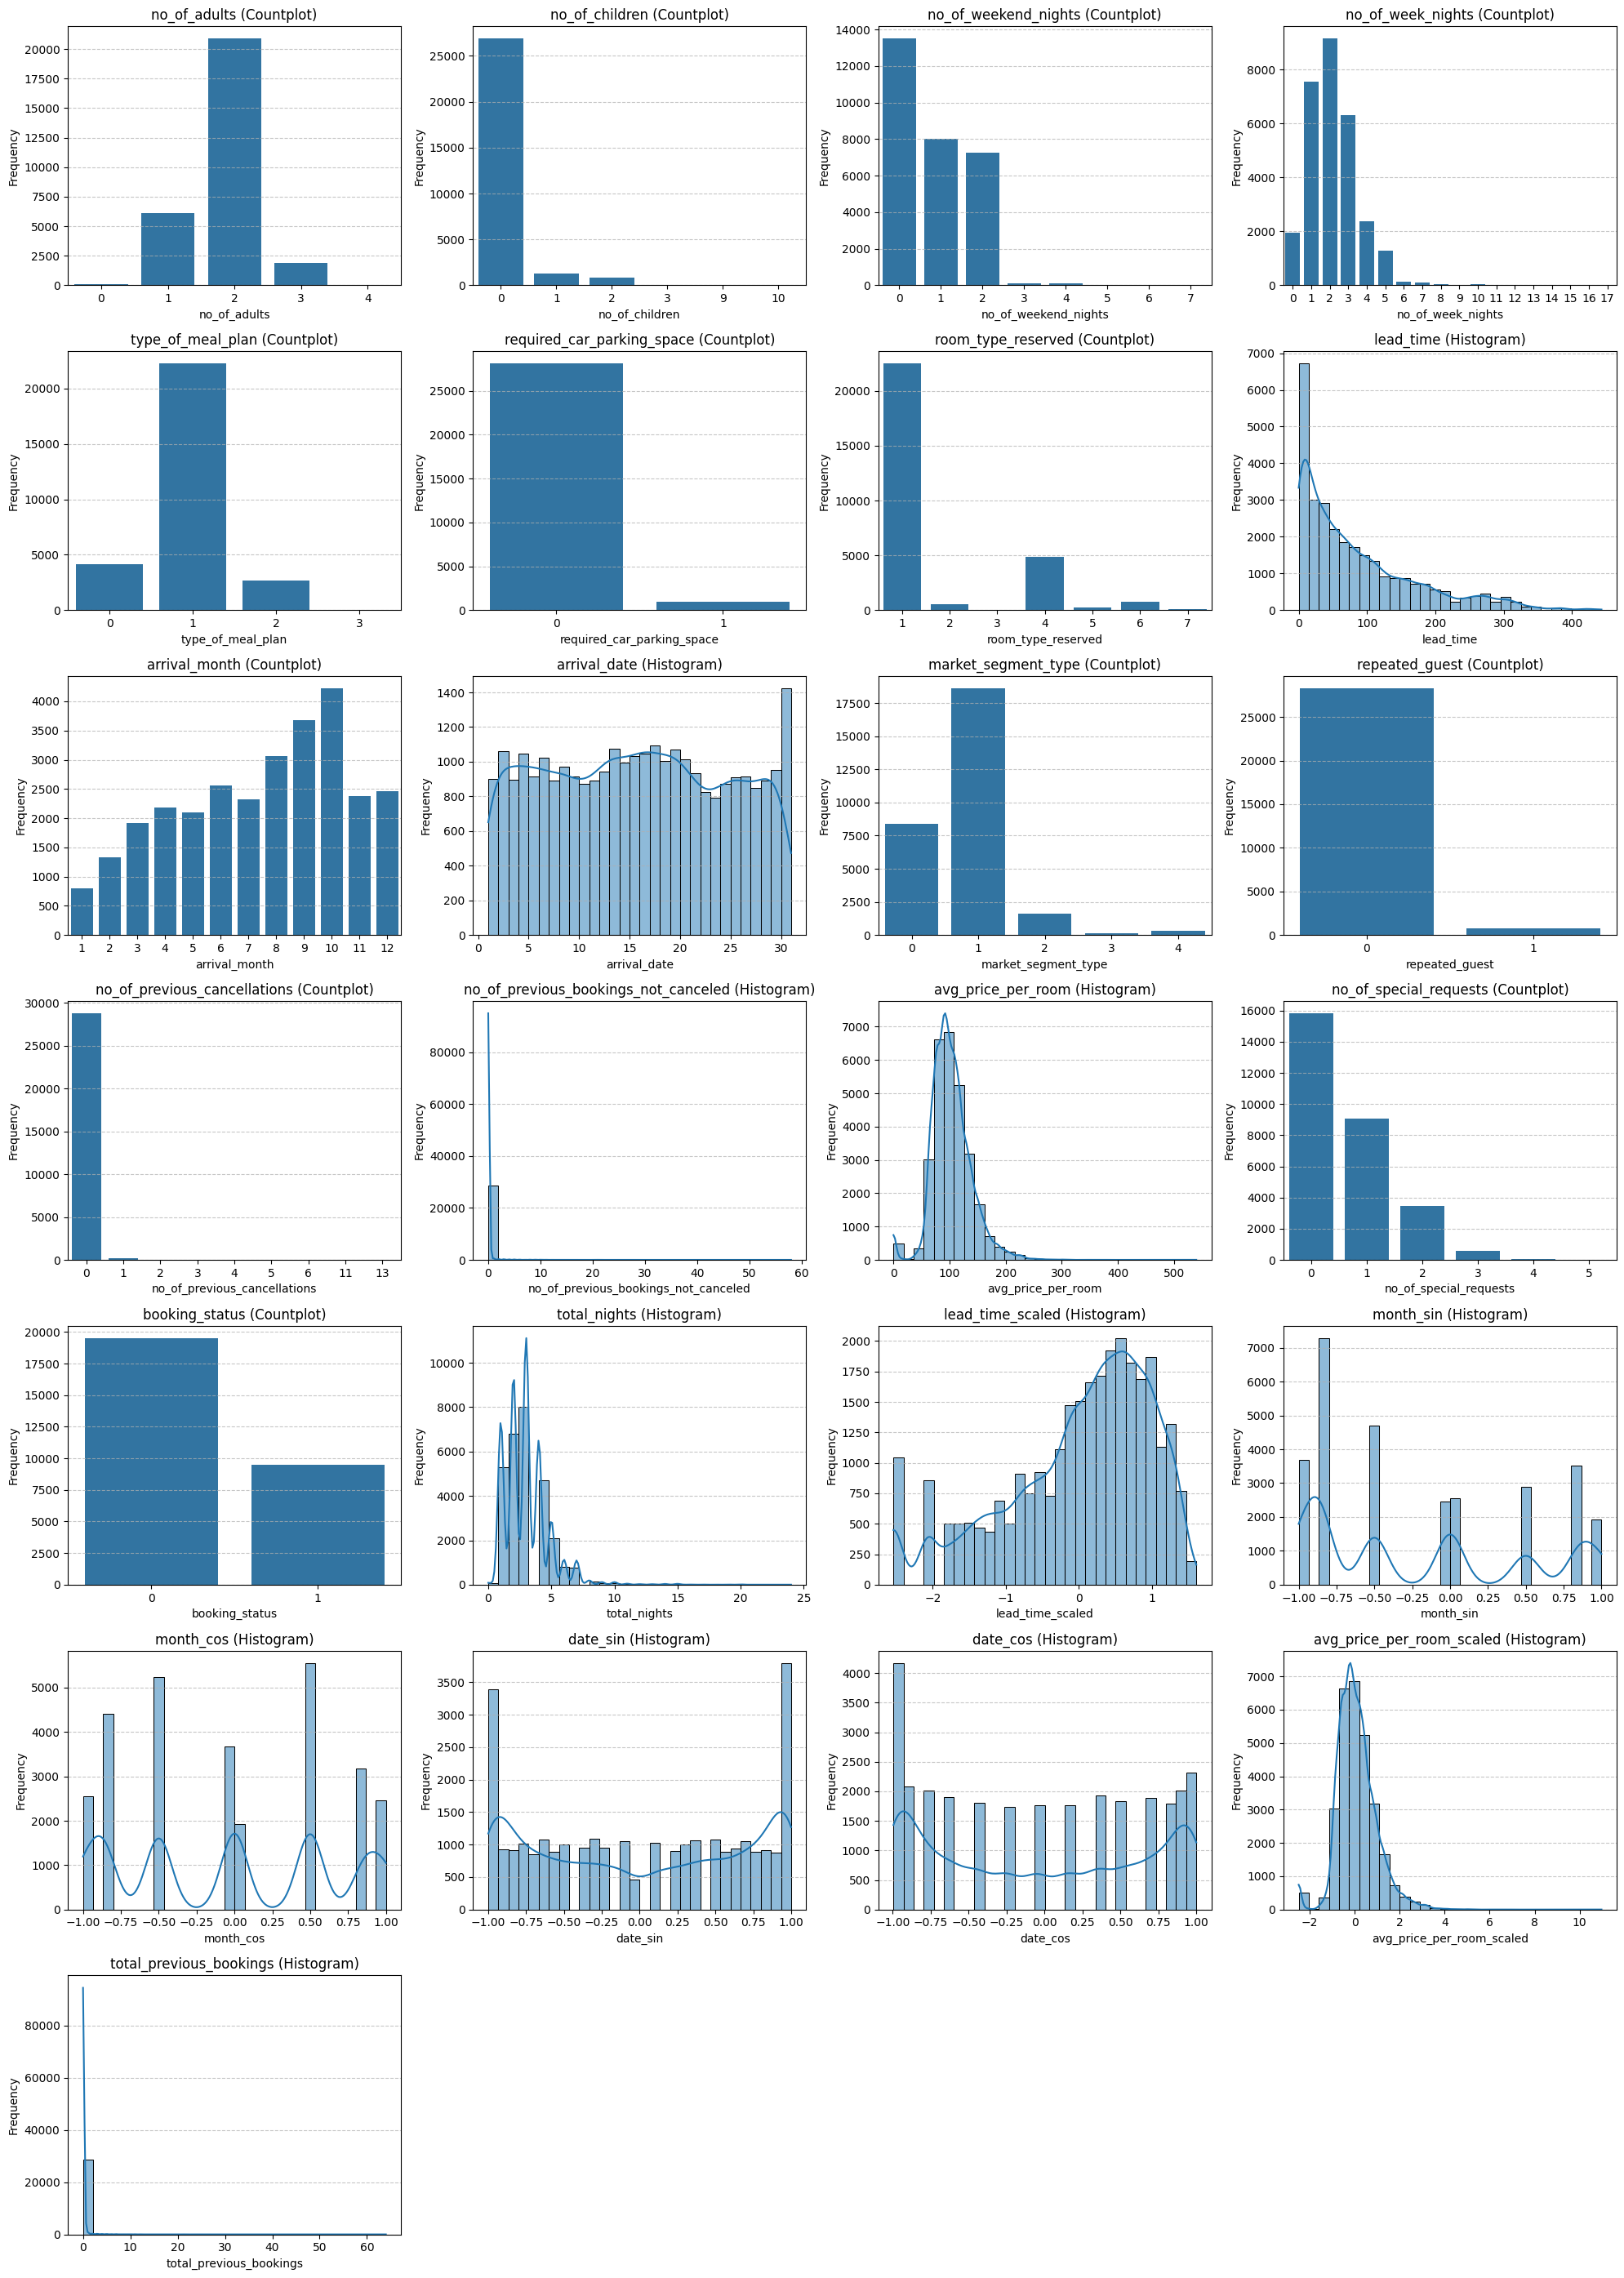

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Get all numerical columns from the updated hotel_train DataFrame
numerical_cols = hotel_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

num_plots = len(numerical_cols)
num_cols_grid = 4  # Number of columns in the plot grid
num_rows_grid = math.ceil(num_plots / num_cols_grid)

plt.figure(figsize=(num_cols_grid * 5, num_rows_grid * 4)) # Adjust overall figure size for better readability

for i, col in enumerate(numerical_cols):
    plt.subplot(num_rows_grid, num_cols_grid, i + 1)

    # Determine whether to use countplot (for low cardinality integers) or histplot
    if hotel_train[col].dtype == 'int64' and hotel_train[col].nunique() < 20:
        sns.countplot(data=hotel_train, x=col) # Removed palette to avoid FutureWarning
        plt.title(f'{col} (Countplot)')
    else:
        sns.histplot(data=hotel_train, x=col, kde=True, bins=30) # Removed palette to avoid UserWarning
        plt.title(f'{col} (Histogram)')

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 상관 히트맵

원본 변수와 파생 변수 드랍 여부는 모델에 따라서 결정하기

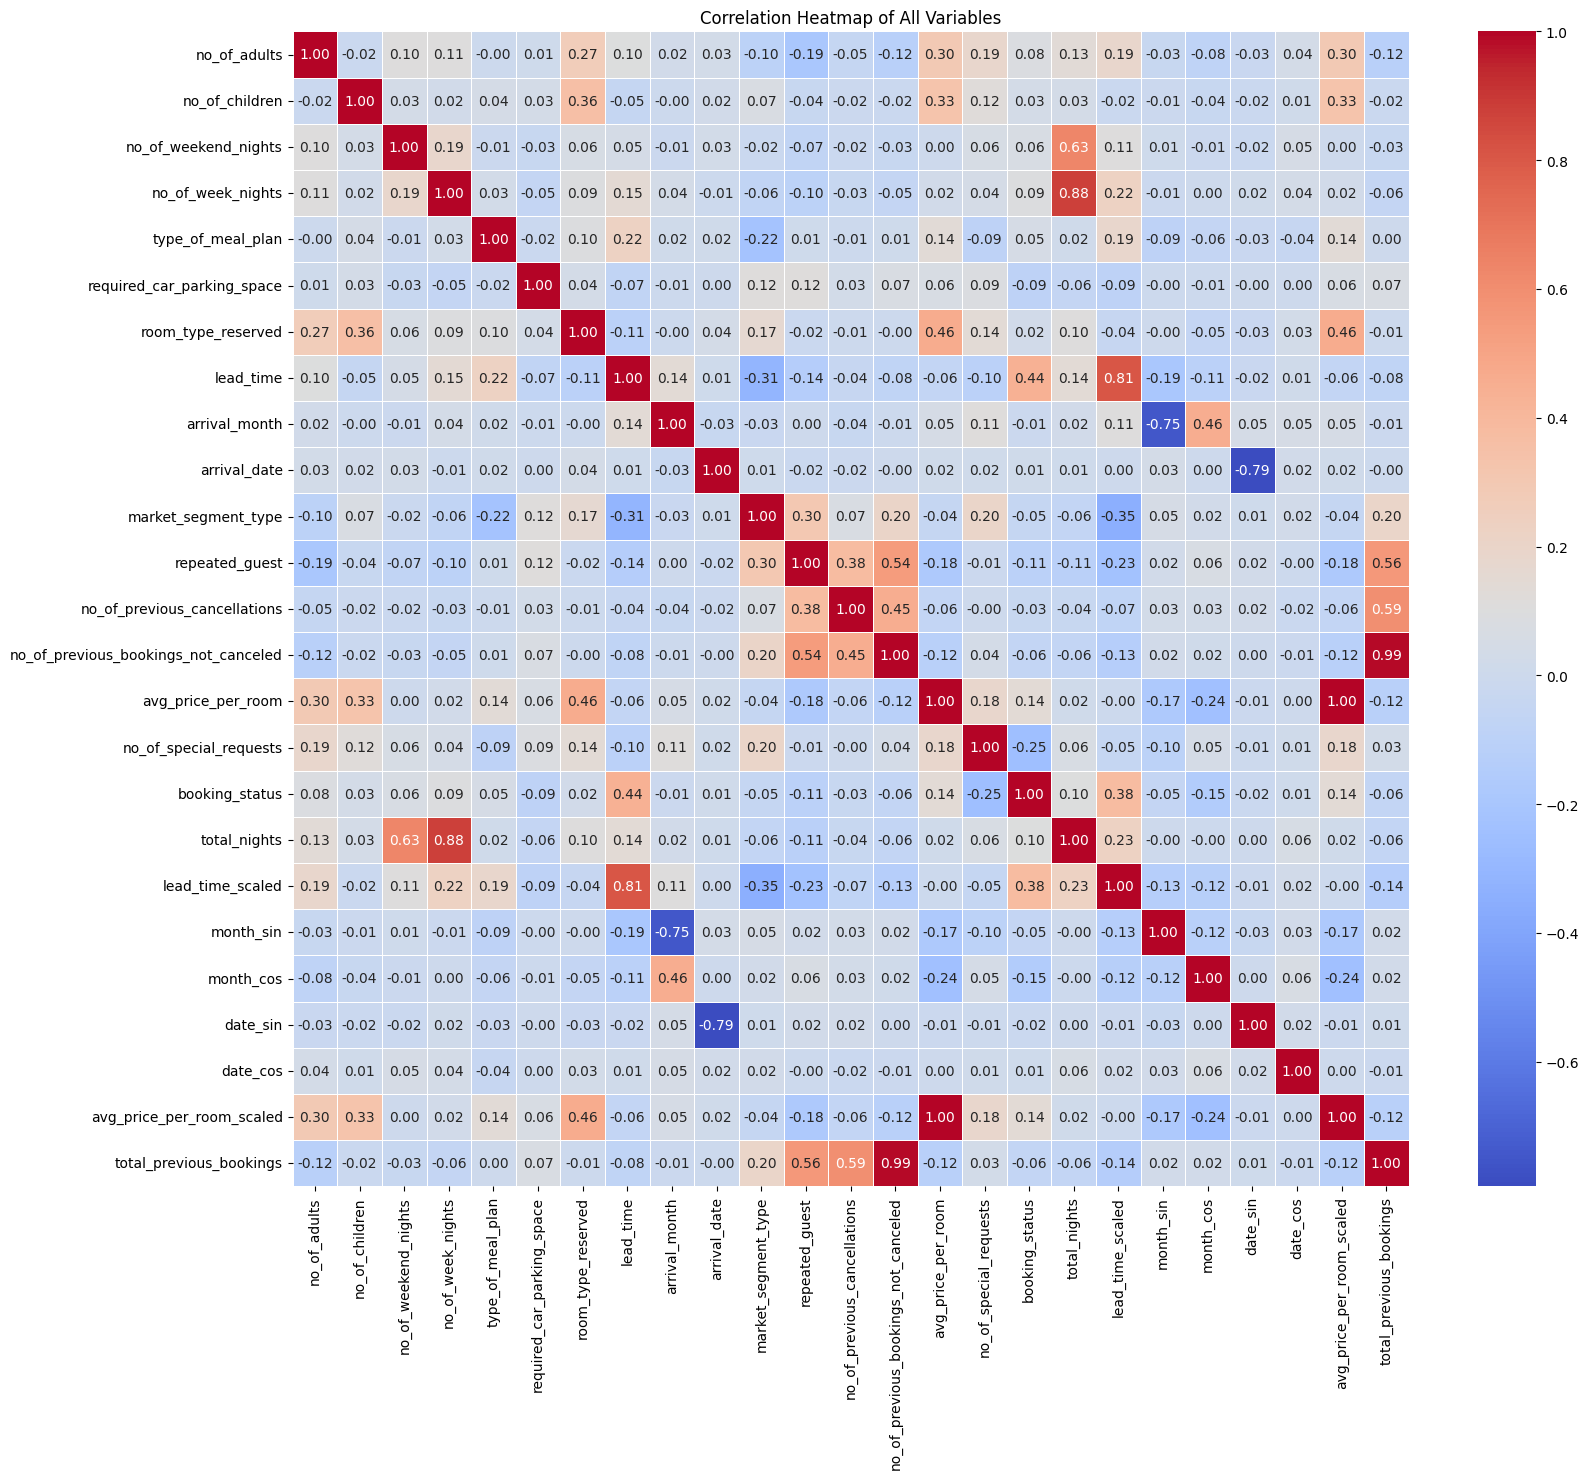

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
corr_matrix = hotel_train.corr(numeric_only=True)

# Set up the matplotlib figure
plt.figure(figsize=(18, 15))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of All Variables')
plt.show()

## 모델링

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)

In [ ]:
X=hotel_train.drop(columns=['booking_status'])
y=hotel_train['booking_status']

In [ ]:
X_train,X_val,y_train,y_val=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23216 entries, 10807 to 11726
Data columns (total 24 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          23216 non-null  int64  
 1   no_of_children                        23216 non-null  int64  
 2   no_of_weekend_nights                  23216 non-null  int64  
 3   no_of_week_nights                     23216 non-null  int64  
 4   type_of_meal_plan                     23216 non-null  int64  
 5   required_car_parking_space            23216 non-null  int64  
 6   room_type_reserved                    23216 non-null  int64  
 7   lead_time                             23216 non-null  int64  
 8   arrival_month                         23216 non-null  int64  
 9   arrival_date                          23216 non-null  int64  
 10  market_segment_type                   23216 non-null  int64  
 11  repeated_guest  

In [ ]:
print(f"학습 데이터:{X_train.shape}")
print(f"검증 데이터:{X_val.shape}")
print(f"타겟 분포:\n{y.value_counts(normalize=True)}")

학습 데이터:(23216, 24)
검증 데이터:(5804, 24)
타겟 분포:
booking_status
0    0.672364
1    0.327636
Name: proportion, dtype: float64


### 모델별 피처 분리

In [ ]:
common_features = [
    'no_of_adults', 'no_of_children',
    'no_of_weekend_nights', 'no_of_week_nights',
    'type_of_meal_plan', 'required_car_parking_space',
    'room_type_reserved', 'market_segment_type',
    'repeated_guest', 'no_of_previous_cancellations',
    'no_of_special_requests',
    'month_sin', 'month_cos',
    'date_sin', 'date_cos',
    'total_nights',
    'total_previous_bookings'
]

# 트리 계열용 (원본 스케일 변수 사용)
tree_features = common_features + [
    'lead_time',
    'avg_price_per_room'
]

# 선형/신경망용 (스케일링된 변수 사용)
linear_features = common_features + [
    'lead_time_scaled',            # Log + Scaled lead_time
    'avg_price_per_room_scaled'   # Robust Scaled avg_price_per_room
]

X_train_tree = X_train[tree_features]
X_val_tree = X_val[tree_features]

X_train_linear = X_train[linear_features]
X_val_linear = X_val[linear_features]

### 평가 지표

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def get_clf_eval(y_test,pred=None,pred_proba=None):
  confusion=confusion_matrix(y_test,pred)
  accuracy=accuracy_score(y_test,pred)
  precision=precision_score(y_test,pred)
  recall=recall_score(y_test,pred)
  f1=f1_score(y_test,pred)
  roc_auc=roc_auc_score(y_test,pred_proba)
  print('오차 행렬:\n',confusion)
  print('정확도:{0:.4f},정밀도:{1:.4f},재현율:{2:.4f},F1:{3:.4f},AUC:{4:.4f}'.format(accuracy,precision,recall,f1,roc_auc))

### LightGBM - 연습용

In [ ]:
import lightgbm as lgb

lgbm_model = lgb.LGBMClassifier(
    n_estimators=100,       # 트리 개수
    max_depth=-1,           # 트리 깊이 (-1이면 제한 없음)
    learning_rate=0.1,      # 학습률
    num_leaves=31,          # 트리의 최대 리프 수 (클수록 복잡한 모델)
    min_child_samples=20,   # 리프 노드의 최소 샘플 수
    random_state=42,
    n_jobs=-1,
    verbose=-1              # 학습 로그 출력 끄기
)

In [ ]:
lgbm_model.fit(
    X_train_tree, y_train,
    eval_set=[(X_val_tree, y_val)],  # 검증 데이터 모니터링
    callbacks=[
        lgb.early_stopping(50),      # 50번 동안 성능 개선 없으면 조기 종료
        lgb.log_evaluation(period=0) # 로그 출력 끄기
    ]
)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.277399


LGBMClassifier(n_jobs=-1, random_state=42, verbose=-1)

In [ ]:
lgbm_pred = lgbm_model.predict(X_val_tree)
lgbm_prob = lgbm_model.predict_proba(X_val_tree)[:, 1]

In [ ]:
print("=" * 50)
print("모델: LightGBM")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_val, lgbm_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, lgbm_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, lgbm_pred,
                            target_names=['비취소', '취소']))

모델: LightGBM
Accuracy : 0.8785
ROC-AUC  : 0.9439

Classification Report:
              precision    recall  f1-score   support

         비취소       0.89      0.94      0.91      3902
          취소       0.85      0.76      0.80      1902

    accuracy                           0.88      5804
   macro avg       0.87      0.85      0.86      5804
weighted avg       0.88      0.88      0.88      5804



#### LightGBM featureimportance

In [ ]:
importance_df = pd.DataFrame({
    'feature': tree_features,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n중요 피처:")
print(importance_df)


중요 피처:
                         feature  importance
17                     lead_time         683
18            avg_price_per_room         621
12                     month_cos         239
10        no_of_special_requests         213
13                      date_sin         176
11                     month_sin         163
14                      date_cos         158
7            market_segment_type         156
3              no_of_week_nights         120
2           no_of_weekend_nights         113
15                  total_nights          98
0                   no_of_adults          70
5     required_car_parking_space          54
6             room_type_reserved          43
4              type_of_meal_plan          40
1                 no_of_children          27
8                 repeated_guest          16
16       total_previous_bookings           8
9   no_of_previous_cancellations           2


#### 중요도 낮은 피처 제거 후 재학습

In [ ]:
low_importance = [
    'repeated_guest',              # 16
    'total_previous_bookings',     # 8
    'no_of_previous_cancellations' # 2
]

tree_features_v2 = [f for f in tree_features
                    if f not in low_importance]

In [ ]:
lgbm_v2 = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

In [ ]:
lgbm_v2.fit(
    X_train[tree_features_v2], y_train,
    eval_set=[(X_val[tree_features_v2], y_val)],
    callbacks=[lgb.early_stopping(50),
               lgb.log_evaluation(period=0)]
)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's binary_logloss: 0.278002


LGBMClassifier(random_state=42, verbose=-1)

In [ ]:
prob_v1 = lgbm_model.predict_proba(X_val[tree_features])[:, 1]
prob_v2 = lgbm_v2.predict_proba(X_val[tree_features_v2])[:, 1]

print(f"기존 모델 ROC-AUC: {roc_auc_score(y_val, prob_v1):.4f}")
print(f"개선 모델 ROC-AUC: {roc_auc_score(y_val, prob_v2):.4f}")

기존 모델 ROC-AUC: 0.9439
개선 모델 ROC-AUC: 0.9442


#### total_nights 재검토

- total_nights를 제거했을 때 ROC-AUC가 낮아짐. 개선 모델 2로 계속 진행.

In [ ]:
tree_features_v3 = [f for f in tree_features_v2
                    if f != 'total_nights']

In [ ]:
lgbm_v3 = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

In [ ]:
lgbm_v3.fit(
    X_train[tree_features_v3], y_train,
    eval_set=[(X_val[tree_features_v3], y_val)],
    callbacks=[lgb.early_stopping(50),
               lgb.log_evaluation(period=0)]
)

Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[99]	valid_0's binary_logloss: 0.279682


LGBMClassifier(random_state=42, verbose=-1)

In [ ]:
prob_v1 = lgbm_model.predict_proba(X_val[tree_features])[:, 1]
prob_v2 = lgbm_v2.predict_proba(X_val[tree_features_v2])[:, 1]
prob_v3 = lgbm_v3.predict_proba(X_val[tree_features_v3])[:, 1]

print(f"기존 모델 ROC-AUC: {roc_auc_score(y_val, prob_v1):.4f}")
print(f"개선 모델2 ROC-AUC: {roc_auc_score(y_val, prob_v2):.4f}")
print(f"개선 모델3 ROC-AUC: {roc_auc_score(y_val, prob_v3):.4f}")

기존 모델 ROC-AUC: 0.9439
개선 모델2 ROC-AUC: 0.9442
개선 모델3 ROC-AUC: 0.9436


#### 하이퍼파라미터 서치 - optuna 이용

In [ ]:
from sklearn.metrics import roc_auc_score
!pip install optuna
import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.4 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42,
        'verbose': -1
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train[tree_features_v2], y_train,
        eval_set=[(X_val[tree_features_v2], y_val)],
        callbacks=[lgb.early_stopping(50),
                   lgb.log_evaluation(period=0)]
    )

    prob = model.predict_proba(X_val[tree_features_v2])[:, 1]
    return roc_auc_score(y_val, prob)

In [ ]:
study = optuna.create_study(direction='maximize')  # ROC-AUC 최대화
study.optimize(objective, n_trials=100)            # 100번 탐색

print(f"최적 파라미터: {study.best_params}")
print(f"최적 ROC-AUC: {study.best_value:.4f}")

[I 2026-03-26 11:01:29,648] A new study created in memory with name: no-name-978293b8-ff94-471d-a96b-e6c6747b305e


Training until validation scores don't improve for 50 rounds


[I 2026-03-26 11:01:30,523] Trial 0 finished with value: 0.9488147036678324 and parameters: {'n_estimators': 422, 'max_depth': 7, 'num_leaves': 34, 'learning_rate': 0.29507310084987143, 'min_child_samples': 20, 'subsample': 0.9464775796744629, 'colsample_bytree': 0.7769878380512957}. Best is trial 0 with value: 0.9488147036678324.


Early stopping, best iteration is:
[138]	valid_0's binary_logloss: 0.262375
Training until validation scores don't improve for 50 rounds


[I 2026-03-26 11:01:32,208] Trial 1 finished with value: 0.9505108329681832 and parameters: {'n_estimators': 313, 'max_depth': 10, 'num_leaves': 63, 'learning_rate': 0.22020649503252548, 'min_child_samples': 42, 'subsample': 0.7300205663129016, 'colsample_bytree': 0.7364017559434217}. Best is trial 1 with value: 0.9505108329681832.


...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[365]	valid_0's binary_logloss: 0.2557


[I 2026-03-26 11:03:12,845] Trial 98 finished with value: 0.9514044403339225 and parameters: {'n_estimators': 434, 'max_depth': 9, 'num_leaves': 46, 'learning_rate': 0.08556970362001791, 'min_child_samples': 46, 'subsample': 0.9654754635584802, 'colsample_bytree': 0.786634701886758}. Best is trial 43 with value: 0.953727455682087.


Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[380]	valid_0's binary_logloss: 0.251331


[I 2026-03-26 11:03:14,574] Trial 99 finished with value: 0.9528785152104585 and parameters: {'n_estimators': 382, 'max_depth': 10, 'num_leaves': 44, 'learning_rate': 0.07293338710156082, 'min_child_samples': 10, 'subsample': 0.9727554481873848, 'colsample_bytree': 0.7322525601554096}. Best is trial 43 with value: 0.953727455682087.


최적 파라미터: {'n_estimators': 248, 'max_depth': 10, 'num_leaves': 60, 'learning_rate': 0.13150102477522047, 'min_child_samples': 16, 'subsample': 0.8890770756831453, 'colsample_bytree': 0.9039359120321395}
최적 ROC-AUC: 0.9537


### XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,   # 트리 개수
    max_depth=6,        # 트리 깊이
    learning_rate=0.1,  # 학습률
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)

In [ ]:
xgb_model.fit(
    X_train_tree, y_train,
    eval_set=[(X_val_tree, y_val)],  # 검증 데이터로 학습 모니터링
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_val_tree)
xgb_prob = xgb_model.predict_proba(X_val_tree)[:, 1]

In [ ]:
print("=" * 50)
print("모델: XGBoost")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_val, xgb_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, xgb_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, xgb_pred,
                            target_names=['비취소', '취소']))

모델: XGBoost
Accuracy : 0.8735
ROC-AUC  : 0.9398

Classification Report:
              precision    recall  f1-score   support

         비취소       0.89      0.93      0.91      3902
          취소       0.84      0.75      0.80      1902

    accuracy                           0.87      5804
   macro avg       0.86      0.84      0.85      5804
weighted avg       0.87      0.87      0.87      5804



#### XGBoost featureimportance

In [ ]:
importance_df_xgb = pd.DataFrame({
    'feature': tree_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df_xgb)

                         feature  importance
7            market_segment_type    0.166187
17                     lead_time    0.152646
10        no_of_special_requests    0.116184
0                   no_of_adults    0.083203
5     required_car_parking_space    0.080065
18            avg_price_per_room    0.060429
2           no_of_weekend_nights    0.057771
12                     month_cos    0.048287
8                 repeated_guest    0.043221
11                     month_sin    0.033710
3              no_of_week_nights    0.031176
4              type_of_meal_plan    0.029459
15                  total_nights    0.021084
6             room_type_reserved    0.019409
13                      date_sin    0.018872
14                      date_cos    0.018392
1                 no_of_children    0.012353
9   no_of_previous_cancellations    0.007551
16       total_previous_bookings    0.000000


#### 하이퍼파라미터 서치 - optuna

In [ ]:
import optuna
import xgboost as xgb
from sklearn.metrics import roc_auc_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def xgb_objective(trial):
    params = {
        # 트리 구조
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10),

        # 학습률
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.3),

        # 과적합 방지
        'subsample'       : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma'           : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0, 5),   # L1 규제
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0, 5),  # L2 규제

        # 고정 파라미터
        'random_state'    : 42,
        'eval_metric'     : 'logloss',
        'n_jobs'          : -1
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train[tree_features], y_train,
        eval_set=[(X_val[tree_features], y_val)],
        verbose=False
    )

    prob = model.predict_proba(X_val[tree_features])[:, 1]
    return roc_auc_score(y_val, prob)

In [ ]:
study = optuna.create_study(direction='maximize')  # ROC-AUC 최대화
study.optimize(xgb_objective, n_trials=100)        # 100번 탐색

In [ ]:
print("=" * 50)
print(f"최적 ROC-AUC : {study.best_value:.4f}")
print(f"최적 파라미터: {study.best_params}")

최적 ROC-AUC : 0.9524
최적 파라미터: {'n_estimators': 450, 'max_depth': 9, 'learning_rate': 0.1580461257871686, 'subsample': 0.9251495772442215, 'colsample_bytree': 0.8406292857011958, 'min_child_weight': 1, 'gamma': 0.18034905734695839, 'reg_alpha': 0.3685650482115297, 'reg_lambda': 4.3959156924470415}


### 랜덤 포레스트

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,   # 트리 개수
    max_depth=None,     # 트리 깊이 제한 없음 (추후 튜닝)
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_model.fit(X_train_tree, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_val_tree)
rf_prob = rf_model.predict_proba(X_val_tree)[:, 1]

In [ ]:
print("=" * 50)
print("모델: RandomForest")
print("=" * 50)
print(f"Accuracy : {accuracy_score(y_val, rf_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, rf_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, rf_pred,
                            target_names=['비취소', '취소']))

모델: RandomForest
Accuracy : 0.9009
ROC-AUC  : 0.9530

Classification Report:
              precision    recall  f1-score   support

         비취소       0.91      0.95      0.93      3902
          취소       0.89      0.80      0.84      1902

    accuracy                           0.90      5804
   macro avg       0.90      0.88      0.88      5804
weighted avg       0.90      0.90      0.90      5804



#### 랜덤포레스트 featureimportance

In [ ]:
importance_df_rf = pd.DataFrame({
    'feature'   : tree_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n중요 피처:")
print(importance_df_rf)


중요 피처:
                         feature  importance
17                     lead_time    0.302934
18            avg_price_per_room    0.148395
10        no_of_special_requests    0.095946
13                      date_sin    0.065994
14                      date_cos    0.059369
7            market_segment_type    0.051817
12                     month_cos    0.046920
15                  total_nights    0.041473
11                     month_sin    0.039013
3              no_of_week_nights    0.037330
2           no_of_weekend_nights    0.029489
0                   no_of_adults    0.024426
4              type_of_meal_plan    0.022404
6             room_type_reserved    0.015521
1                 no_of_children    0.007996
5     required_car_parking_space    0.006275
8                 repeated_guest    0.002359
16       total_previous_bookings    0.002043
9   no_of_previous_cancellations    0.000295


#### 중요도 낮은 피처 제거 후 재학습

In [ ]:
remove_features_rf = [
    'repeated_guest',               # 0.002359
    'total_previous_bookings',      # 0.002043
    'no_of_previous_cancellations'  # 0.000295
]

tree_features_rf_v2 = [f for f in tree_features
                        if f not in remove_features_rf]

print(f"기존 피처 수: {len(tree_features)}")
print(f"개선 피처 수: {len(tree_features_rf_v2)}")

기존 피처 수: 19
개선 피처 수: 16


In [ ]:
rf_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_v2.fit(X_train[tree_features_rf_v2], y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
rf_v2_prob = rf_v2.predict_proba(X_val[tree_features_rf_v2])[:, 1]
rf_base_prob = rf_model.predict_proba(X_val[tree_features])[:, 1]

print("\n" + "=" * 50)
print("피처 제거 전/후 성능 비교")
print("=" * 50)
print(f"기존 ROC-AUC: {roc_auc_score(y_val, rf_base_prob):.4f}")
print(f"개선 ROC-AUC: {roc_auc_score(y_val, rf_v2_prob):.4f}")


피처 제거 전/후 성능 비교
기존 ROC-AUC: 0.9530
개선 ROC-AUC: 0.9530


#### 하이퍼파라미터 서치 - optuna 이용

In [ ]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
def rf_objective(trial):
    params = {
        # 트리 개수
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),

        # 트리 깊이
        'max_depth': trial.suggest_int('max_depth', 3, 20),

        # 분할 조건
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 20),

        # 피처 샘플링
        'max_features': trial.suggest_categorical(
            'max_features', ['sqrt', 'log2', 0.5, 0.7]
        ),

        # 고정 파라미터
        'random_state': 42,
        'n_jobs'      : -1
    }

    model = RandomForestClassifier(**params)
    # Changed 'best_rf_features' to 'tree_features_rf_v2'
    model.fit(X_train[tree_features_rf_v2], y_train)

    prob = model.predict_proba(X_val[tree_features_rf_v2])[:, 1]
    return roc_auc_score(y_val, prob)

In [ ]:
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(rf_objective, n_trials=100)

print("\n" + "=" * 50)
print(f"최적 ROC-AUC : {study_rf.best_value:.4f}")
print(f"최적 파라미터: {study_rf.best_params}")


최적 ROC-AUC : 0.9537
최적 파라미터: {'n_estimators': 163, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 0.5}
